## Pathway enrichment (ORA)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scanpy as sc
import pandas as pd
import ma_codes as codes
from ma_codes import mysize, gray_red, mymap
import pertpy as pt
import seaborn as sns
from pathlib import Path
import math
import re
import gseapy as gp

try:
    from adjustText import adjust_text
    HAS_ADJUSTTEXT = True
except ImportError:
    HAS_ADJUSTTEXT = False

sc.settings.verbosity = 3               # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_version_and_date()

Running Scanpy 1.11.4, on 2026-08-13 12:05.


In [2]:
plt.rcParams['pdf.fonttype'] = 42

In [3]:
# Endothelial cells in endothelial compartments
dge_folder_mild   = "/media/synology/Huijuan/IPF_EC paper/snRNA_IPF_mild_severe/DGE_EC_celltype_MAST/DEG_IPF_Mild_Control/"
dge_folder_severe = "/media/synology/Huijuan/IPF_EC paper/snRNA_IPF_mild_severe/DGE_EC_celltype_MAST/DEG_IPF_Severe_Control/"

## aCap

In [4]:
cell_type_filename = "diffExpResults_aCap.xlsx"
out_base = "/media/synology/Huijuan/Plots/IPF_subsets/IPF_paper/MAST_EC_pathway/new/aCap/"

ct_label   = "aCap"
ct_color   = "#f3cfe2"
pval_thresh = 0.05
lfc_thresh  = 0.3
TOP_N_LABEL = 20
#GENE_SETS   = ['GO_Biological_Process_2025', 'Reactome_2022', 'MSigDB_Hallmark_2020']

In [5]:
# load DGE table
def load_dge(folder, fname):
    df = pd.read_excel(Path(folder) / fname)
    df = df.rename(columns={"Unnamed: 0": "gene"})
    return df

# Get up/down regulated gene list: p<0.05, |log2FC|>0.5
def get_up_down_genes(df, pval_col="p_val", lfc_col="avg_log2FC",
                       pval_thresh=0.05, lfc_thresh=0.5):
    sub = df.dropna(subset=[pval_col, lfc_col, "gene"])
    up = sub[(sub[pval_col] < pval_thresh) & (sub[lfc_col] > lfc_thresh)]["gene"].tolist()
    down = sub[(sub[pval_col] < pval_thresh) & (sub[lfc_col] < -lfc_thresh)]["gene"].tolist()
    return up, down

# pathway enrichment
def run_enrichr_up_down(glist_up, glist_down, outdir_up, outdir_down):
    enr_up = gp.enrichr(
        gene_list=glist_up,
        organism='Human',
        gene_sets=['GO_Biological_Process_2025', 'Reactome_2022', 'MSigDB_Hallmark_2020'],
        cutoff=0.05,  # p value
        outdir=outdir_up,
        no_plot=True,
    )
    enr_down = gp.enrichr(
        gene_list=glist_down,
        organism='Human',
        gene_sets=['GO_Biological_Process_2025', 'Reactome_2022', 'MSigDB_Hallmark_2020'],
        cutoff=0.05,
        outdir=outdir_down,
        no_plot=True,
    )
    return enr_up, enr_down

# load enrichment result
def load_results(outdir, gene_set):
    return pd.read_csv(Path(outdir) / f"{gene_set}.Human.enrichr.reports.txt", delimiter="\t")

# ── enrichment bar plot
def make_barplot(go_df, msig_df, go_idx, msig_idx, title, savepath=None,
                  figsize=(2, 3), palette="Reds"):
    go_sel = go_df.iloc[go_idx]
    msig_sel = msig_df.iloc[msig_idx]

    selection = pd.concat([msig_sel, go_sel], axis=0)
    selection["-log10(p_adj)"] = selection["Adjusted P-value"].apply(lambda x: -math.log10(x))
    selection.sort_values(by="-log10(p_adj)", ascending=False, inplace=True)

    fig, ax = plt.subplots()
    fig.set_size_inches(*figsize)
    sns.barplot(
        selection, x="-log10(p_adj)", y="Term", orient="y",
        hue="Gene_set", palette=palette,
        hue_order=["GO_Biological_Process_2025", "MSigDB_Hallmark_2020"]
    )
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.title(title, loc='center')
    if savepath:
        plt.savefig(savepath, bbox_inches="tight")
    return fig, selection

# ── volcano plot ───────────────────────────────────────────────────────────────
def plot_volcano(
    df,
    condition,
    savepath=None,
    save=True,
    show=True,
    pval_col="p_val",
    lfc_col="avg_log2FC",
    figsize=(5, 4.5)
):
    df = df.dropna(subset=[pval_col, lfc_col, "gene"]).copy()

    df["-log10p"] = -np.log10(df[pval_col].clip(lower=1e-300))

    def status(r):
        if r[pval_col] < pval_thresh and r[lfc_col] > lfc_thresh:
            return "up"
        if r[pval_col] < pval_thresh and r[lfc_col] < -lfc_thresh:
            return "down"
        return "ns"

    df["status"] = df.apply(status, axis=1)

    n_up = (df["status"] == "up").sum()
    n_down = (df["status"] == "down").sum()

    color_map = {"up": ct_color, "down": "#4477AA", "ns": "#cccccc"}
    size_map = {"up": 18, "down": 18, "ns": 4}
    alpha_map = {"up": 0.85, "down": 0.85, "ns": 0.3}

    fig, ax = plt.subplots(figsize=figsize)

    for s in ["ns", "down", "up"]:
        sub = df[df["status"] == s]

        ax.scatter(
            sub[lfc_col],
            sub["-log10p"],
            s=size_map[s],
            c=color_map[s],
            alpha=alpha_map[s],
            linewidths=0,
            zorder=1 if s == "ns" else 3,
            rasterized=(s == "ns"),
        )

    ax.axhline(-np.log10(pval_thresh), color="#888888", lw=0.8, ls="--", zorder=2)
    ax.axvline(lfc_thresh, color="#888888", lw=0.8, ls="--", zorder=2)
    ax.axvline(-lfc_thresh, color="#888888", lw=0.8, ls="--", zorder=2)
    ax.axvline(0, color="#444444", lw=0.5, ls="-", zorder=2)

    top = pd.concat([
        df[df["status"] == "up"].nlargest(TOP_N_LABEL, "-log10p"),
        df[df["status"] == "down"].nlargest(TOP_N_LABEL, "-log10p"),
    ])

    texts = [
        ax.text(
            r[lfc_col],
            r["-log10p"],
            r["gene"],
            fontsize=6.5,
            color="#222222",
        )
        for _, r in top.iterrows()
    ]

    if HAS_ADJUSTTEXT:
        adjust_text(
            texts,
            ax=ax,
            arrowprops=dict(arrowstyle="-", color="#aaaaaa", lw=0.5),
        )

    xlim, ylim = ax.get_xlim(), ax.get_ylim()

    ax.text(
        xlim[1] * 0.97,
        ylim[1] * 0.97,
        f"Up: {n_up}",
        ha="right",
        va="top",
        fontsize=8,
        color=ct_color,
        fontweight="bold",
    )

    ax.text(
        xlim[0] * 0.97,
        ylim[1] * 0.97,
        f"Down: {n_down}",
        ha="left",
        va="top",
        fontsize=8,
        color="#4477AA",
        fontweight="bold",
    )

    ax.set_xlabel("log2 Fold Change", fontsize=10)
    ax.set_ylabel("–log10(p value)", fontsize=10)

    ax.set_title(
        f"{ct_label} — {condition}\n"
        f"threshold: p < {pval_thresh}, |log2FC| > {lfc_thresh}",
        fontsize=9,
        fontweight="bold",
    )

    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)

    plt.tight_layout()

    if save:
        if savepath is None:
            raise ValueError("savepath must be provided when save=True")

        plt.savefig(savepath, bbox_inches="tight", dpi=300)
        print(f"  Saved: {Path(savepath).name}")

    if show:
        plt.show()

    plt.close(fig)

## Mild vs control

In [6]:
df_mild = load_dge(dge_folder_mild, cell_type_filename)
df_mild.head()

,gene,entrezgene,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,mean_IPF_Mild,mean_Control
0,AFF3,3899.0,3.764958e-101,-0.044404,0.953,0.901,1.171843e-96,2.453905,2.482073
1,NCKAP5,344148.0,5.362841e-99,3.145044,0.494,0.073,1.669184e-94,1.093795,0.201993
2,TCF4,6925.0,2.698364e-90,1.486639,0.938,0.681,8.398658e-86,2.102999,1.271301
3,XIST,7503.0,3.891359e-80,0.394422,0.368,0.234,1.211186e-75,0.638607,0.518695
4,COL4A2,1284.0,3.298677e-79,1.578513,0.728,0.335,1.026713e-74,1.205413,0.577960


In [7]:
glist_mild_up, glist_mild_down = get_up_down_genes(df_mild, pval_thresh=pval_thresh, lfc_thresh=lfc_thresh)
print(f"Mild vs Control DEGs— up: {len(glist_mild_up)}, down: {len(glist_mild_down)}")

Mild vs Control DEGs— up: 3765, down: 825


In [8]:
print(glist_mild_up)

['NCKAP5', 'TCF4', 'XIST', 'COL4A2', 'LDB2', 'EPB41L4A', 'SORBS1', 'SH3RF3', 'RAPGEF5', 'ID1', 'MAGI1', 'PRICKLE2', 'GRK5', 'SIK2', 'PACS1', 'WWTR1', 'COL4A1', 'PIK3R3', 'AC010974.2', 'F2RL3', 'SGK1', 'RGCC', 'PLXNA2', 'PTCHD4', 'WARS', 'CMTM8', 'PLPP3', 'PRKCE', 'SMAD6', 'ID3', 'IL1RL1', 'FENDRR', 'JAG1', 'BCL2L14', 'CLDN5', 'ACSL3', 'ADAM19', 'AL157871.4', 'MN1', 'SEC14L1', 'SMURF2', 'PODXL', 'AL356124.1', 'CFAP161', 'SUFU', 'PRDM1', 'RALGAPA2', 'TGFBR1', 'VPS37A', 'ENG', 'TRIM8', 'ADCY4', 'HYAL2', 'VIPR1', 'ITGA1', 'FAT1', 'ABHD17C', 'PXDN', 'SEMA3A', 'DOCK6', 'ITPKB', 'PDGFB', 'CEMIP2', 'TBX3', 'FOXF1', 'HLA-B', 'SLC26A2', 'AL353138.1', 'FZD4', 'AL137139.2', 'TMEM100', 'SPOCK2', 'PDE8A', 'AUTS2', 'PHLDA1', 'EML1', 'TMEM108', 'HLA-E', 'NAV1', 'SKIL', 'FKBP1A', 'NFKBIA', 'HLA-A', 'PREX1', 'PALD1', 'LRP6', 'BMPR2', 'GLUD1', 'ZSWIM6', 'BICD1', 'SNRK', 'STARD4', 'MAGI1-AS1', 'NCKAP5-AS1', 'ABCG1', 'STXBP6', 'TMEM184B', 'PREP', 'BMP6', 'SIPA1L2', 'RAPGEF1', 'SASH1', 'LINC02802', 'COBLL1'

  Saved: volcano_aCap_mild_vs_control.pdf


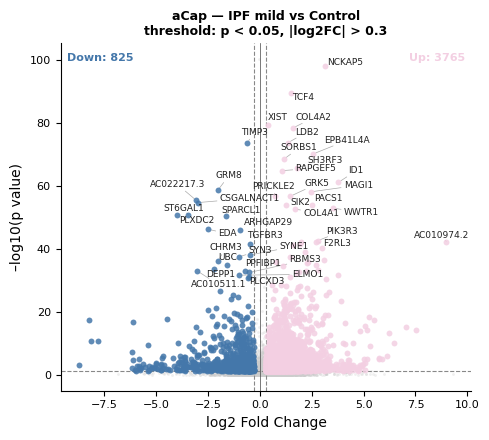

In [9]:
plot_volcano(df_mild, "IPF mild vs Control", save =True, show = True,
             savepath=out_base +"volcano_aCap_mild_vs_control.pdf")

In [10]:
enr_mild_up, enr_mild_down = run_enrichr_up_down(
    glist_mild_up, glist_mild_down,
    outdir_up=f"{out_base}/mild_up",
    outdir_down=f"{out_base}/mild_down",
)

### Upregulated pythways

In [11]:
GO_mild_up   = load_results(f"{out_base}/mild_up", "GO_Biological_Process_2025")
GO_mild_up.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Ubiquitin-Dependent Protein Catabolic Process ...,173/455,2.890095e-22,1.356611e-18,0,0,2.724602,135.12820,UBE3D;UBXN2A;UBE2D2;UBE2D3;KEAP1;UBE3B;FBXO22;...
1,GO_Biological_Process_2025,Proteasomal Protein Catabolic Process (GO:0010...,136/372,3.954802e-16,9.281919e-13,0,0,2.540579,90.10528,MIDN;UBE3D;UBXN2A;UBE2D3;KEAP1;DCAF1;UXT;PSMD6...
2,GO_Biological_Process_2025,Protein Polyubiquitination (GO:0000209),95/228,1.015879e-15,1.376592e-12,0,0,3.133904,108.19180,UBE3D;RNF14;UBE2D2;UBE2D3;TNFAIP3;UBE3B;FBXO22...
3,GO_Biological_Process_2025,Protein Ubiquitination (GO:0016567),134/369,1.211987e-15,1.376592e-12,0,0,2.512642,86.30051,UBE3D;UBE2D2;UBE2D3;KEAP1;UBE3B;FBXO22;RNF112;...
4,GO_Biological_Process_2025,Proteasome-Mediated Ubiquitin-Dependent Protei...,126/340,1.466331e-15,1.376592e-12,0,0,2.592175,88.53837,UBE3D;UBXN2A;UBE2D3;LTN1;KEAP1;DCAF1;UXT;PSMD6...
5,GO_Biological_Process_2025,Modification-Dependent Protein Catabolic Proce...,87/208,1.239964e-14,9.700653e-12,0,0,3.150109,100.87000,RNF11;RNF13;RNF14;UBE2D2;UBE2D3;KEAP1;ARRB1;UB...
6,GO_Biological_Process_2025,Protein Modification by Small Protein Conjugat...,114/316,2.722660e-13,1.825738e-10,0,0,2.478315,71.70259,ZNF451;UBE2D2;UBE2D3;KEAP1;SMC5;HERC3;RNF115;Z...
7,GO_Biological_Process_2025,Intracellular Protein Transport (GO:0006886),103/326,1.808711e-08,1.061261e-05,0,0,2.019573,36.00508,VPS29;MTCH1;MTCH2;TOMM20;RAB43;IPO8;IPO9;KPNA6...
8,GO_Biological_Process_2025,Protein Localization to Nucleus (GO:0034504),50/127,5.387756e-08,2.810014e-05,0,0,2.824282,47.26874,INTS13;ADAR;LMNB1;IPO8;HHEX;IPO9;KPNA6;KPNA4;K...
9,GO_Biological_Process_2025,Protein K48-linked Ubiquitination (GO:0070936),39/91,1.092301e-07,5.127259e-05,0,0,3.257448,52.21627,RNF34;ANAPC16;UBE2D2;CUL3;UBE2D3;CUL1;UBR4;TNF...


In [12]:
Msig_mild_up = load_results(f"{out_base}/mild_up", "MSigDB_Hallmark_2020")
Msig_mild_up.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,TGF-beta Signaling,32/54,5.369935e-11,2.684967e-09,0,0,6.317317,149.389500,CDKN1C;BCAR3;BMPR2;SLC20A1;UBE2D3;XIAP;FNTA;JU...
1,MSigDB_Hallmark_2020,Interferon Gamma Response,67/200,5.218546e-07,1.304637e-05,0,0,2.193492,31.730790,IFITM3;OGFR;CD40;CDKN1A;IFITM2;BTG1;SPPL2A;TNF...
2,MSigDB_Hallmark_2020,Myc Targets V1,63/200,1.100991e-05,1.834985e-04,0,0,1.999657,22.829510,EIF4A1;SLC25A3;RPL34;EEF1B2;SYNCRIP;PSMD7;YWHA...
3,MSigDB_Hallmark_2020,Mitotic Spindle,60/199,7.329879e-05,7.145822e-04,0,0,1.875280,17.854480,TRIO;ARHGAP5;SMC4;ARHGAP4;LMNB1;UXT;PREX1;CAPZ...
4,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,60/200,8.574987e-05,7.145822e-04,0,0,1.861770,17.433750,BTG2;CDKN1A;BTG1;B4GALT1;TNFAIP3;AREG;SLC2A6;E...
5,MSigDB_Hallmark_2020,Oxidative Phosphorylation,60/200,8.574987e-05,7.145822e-04,0,0,1.861770,17.433750,SLC25A3;MTRR;COX4I1;MRPS12;ETFA;ETFB;MTRF1;CAS...
6,MSigDB_Hallmark_2020,PI3K/AKT/mTOR Signaling,36/105,1.227853e-04,8.770380e-04,0,0,2.261849,20.368120,ATF1;GSK3B;CDKN1A;ARF1;CAB39;YWHAB;UBE2D3;CLTC...
7,MSigDB_Hallmark_2020,p53 Pathway,57/200,5.443709e-04,3.402318e-03,0,0,1.729853,13.001360,RB1;CCNK;CDKN1A;BTG2;BTG1;CD81;PITPNC1;FDXR;KI...
8,MSigDB_Hallmark_2020,Interferon Alpha Response,32/97,6.175314e-04,3.430730e-03,0,0,2.132498,15.758690,IFITM3;OGFR;RNF31;IFITM2;SAMD9;ADAR;IFI35;TMEM...
9,MSigDB_Hallmark_2020,Protein Secretion,31/96,1.111489e-03,5.557446e-03,0,0,2.065304,14.048310,ARF1;TMED10;TSG101;COPB1;GOSR2;CLTC;CLTA;ATP1A...


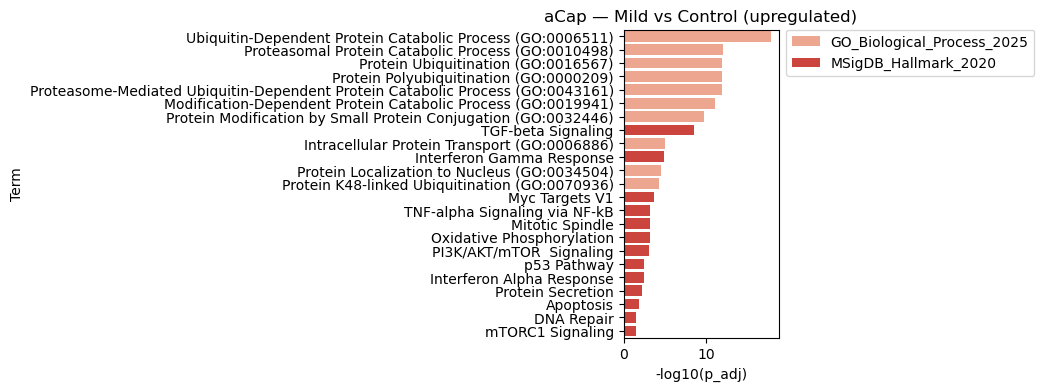

In [13]:
fig_mild_up, sel_mild_up = make_barplot(
    GO_mild_up, Msig_mild_up,
    go_idx=range(0, 10), msig_idx=range(0, 13),
    title="aCap — Mild vs Control (upregulated)",
    savepath=f"{out_base}/aCap_mild_up.pdf",
    figsize=(2, 4)
)

### Downregulated pathways

In [14]:
GO_mild_down   = load_results(f"{out_base}/mild_down", "GO_Biological_Process_2025")
GO_mild_down.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Regulation of Protein Modification by Small Pr...,7/28,0.000110,0.164015,0,0,7.805216,71.16751,PRKN;HSP90AA1;PINK1;HSP90AB1;WASHC1;HSPA1B;HSPA1A
1,GO_Biological_Process_2025,"Regulation of mRNA Splicing, via Spliceosome (...",13/97,0.000173,0.164015,0,0,3.638620,31.52335,RBM39;KHDRBS2;RBM25;KHDRBS3;YTHDC1;CIRBP;HNRNP...
2,GO_Biological_Process_2025,Regulation of Cell-Matrix Adhesion (GO:0001952),10/65,0.000309,0.164015,0,0,4.265477,34.47543,DAPK3;CDH13;PTK2B;EMP2;SEMA3E;CD36;UTRN;EPHA3;...
3,GO_Biological_Process_2025,Regulation of RNA Splicing (GO:0043484),13/104,0.000348,0.164015,0,0,3.357495,26.73553,RBM39;MBNL1;AHNAK;YTHDC1;TAF10;AKAP17A;SUPT3H;...
4,GO_Biological_Process_2025,Response to Unfolded Protein (GO:0006986),8/44,0.000384,0.164015,0,0,5.205766,40.94672,PRKN;DNAJB1;HSPA8;HSP90AA1;HSP90AB1;HSPH1;HSPE...
5,GO_Biological_Process_2025,Chaperone Cofactor-Dependent Protein Refolding...,6/25,0.000437,0.164015,0,0,7.386158,57.14018,DNAJB1;HSPA8;PTGES3;HSPE1;HSPA1B;HSPA1A
6,GO_Biological_Process_2025,Synaptic Signaling (GO:0099536),4/10,0.000494,0.164015,0,0,15.565570,118.48520,GRID2;DTNA;GRID1;UTRN
7,GO_Biological_Process_2025,Regulation of Monoatomic Anion Transport (GO:0...,3/5,0.000657,0.164015,0,0,34.987230,256.37970,ATP8B1;CA2;STC1
8,GO_Biological_Process_2025,Regulation of Mitochondrial Fission (GO:0090140),6/27,0.000680,0.164015,0,0,6.682016,48.73083,PRKN;PINK1;BNIP3;STAT2;PPARG;DCN
9,GO_Biological_Process_2025,Positive Regulation of Erythrocyte Differentia...,6/27,0.000680,0.164015,0,0,6.682016,48.73083,HMGB2;FOXO3;ETS1;GLUL;HSPA1B;HSPA1A


In [15]:
Msig_mild_down = load_results(f"{out_base}/mild_down", "MSigDB_Hallmark_2020")
Msig_mild_down.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,Hypoxia,26/200,2.263132e-07,0.000011,0,0,3.553479,54.373010,SCARB1;PFKFB3;SDC2;STC1;RBPJ;FOXO3;ETS1;NDRG1;...
1,MSigDB_Hallmark_2020,UV Response Dn,20/144,1.961772e-06,0.000047,0,0,3.817071,50.162650,YTHDC1;SDC2;CAV1;ANXA4;ATRX;MRPS31;ADD3;RND3;S...
2,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,20/200,2.396081e-04,0.003834,0,0,2.621808,21.856720,JUN;ECM2;DST;IL15;LUM;ELN;TPM2;TPM1;FN1;FBLN1;...
3,MSigDB_Hallmark_2020,Estrogen Response Early,17/200,3.924938e-03,0.047099,0,0,2.183520,12.097580,FARP1;SVIL;SCARB1;RHOBTB3;FOS;GAB2;ADCY1;ADD3;...
4,MSigDB_Hallmark_2020,Fatty Acid Metabolism,14/158,5.879346e-03,0.055329,0,0,2.281426,11.718110,AOC3;HSP90AA1;DHCR24;HSD17B11;HSPH1;AUH;CA2;ME...
5,MSigDB_Hallmark_2020,Apoptosis,14/161,6.916105e-03,0.055329,0,0,2.234514,11.114250,JUN;ANXA1;LUM;HGF;CAV1;HMGB2;SAT1;DCN;TGFBR3;D...
6,MSigDB_Hallmark_2020,IL-2/STAT5 Signaling,16/199,8.496769e-03,0.058264,0,0,2.052537,9.786641,ITIH5;PHTF2;AHCY;AHNAK;ANXA4;NDRG1;AGER;TIAM1;...
7,MSigDB_Hallmark_2020,Adipogenesis,15/200,1.897094e-02,0.113826,0,0,1.900901,7.536781,ITIH5;SCARB1;PFKFB3;FABP4;NKIRAS1;UBC;ME1;PDCD...
8,MSigDB_Hallmark_2020,Androgen Response,9/100,2.233414e-02,0.119115,0,0,2.313025,8.793286,TPD52;INPP4B;TNFAIP8;MAK;ARID5B;PTK2B;DHCR24;S...
9,MSigDB_Hallmark_2020,Estrogen Response Late,14/200,3.799917e-02,0.180456,0,0,1.762367,5.763276,FARP1;SCARB1;MOCS2;CAV1;EMP2;FOS;ADD3;SCUBE2;T...


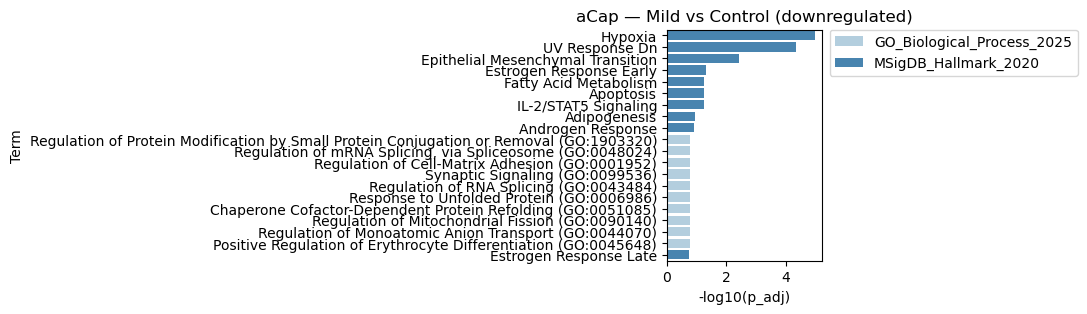

In [16]:
fig_mild_down, sel_mild_down = make_barplot(
    GO_mild_down, Msig_mild_down,
    go_idx=range(0, 10), msig_idx=range(0, 10),
    title="aCap — Mild vs Control (downregulated)",
    savepath=f"{out_base}/aCap_mild_down.pdf",
    palette="Blues",
)

## Severe vs control

In [17]:
df_severe = load_dge(dge_folder_severe, cell_type_filename)
df_severe.head()

,gene,entrezgene,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,mean_IPF_Severe,mean_Control
0,ZNF700,90592.0,4.041979e-07,1.872033,0.075,0.021,0.012581,0.080761,0.023289
1,EIF1B-AS1,NaN,3.255623e-06,1.308604,0.042,0.025,0.101331,0.076442,0.032723
2,CAPN1,823.0,4.012253e-06,0.615885,0.056,0.040,0.124881,0.063370,0.044060
3,MED24,9862.0,5.756903e-06,1.809972,0.084,0.032,0.179184,0.110488,0.033393
4,PREP,5550.0,2.038331e-05,2.552856,0.350,0.066,0.634431,0.423984,0.086260


In [18]:
glist_severe_up, glist_severe_down = get_up_down_genes(df_severe, pval_thresh=pval_thresh, lfc_thresh=lfc_thresh)
print(f"Severe vs Control DEGs— up: {len(glist_severe_up)}, down: {len(glist_severe_down)}")

Severe vs Control DEGs— up: 193, down: 9


In [19]:
print(glist_severe_up)

['ZNF700', 'EIF1B-AS1', 'CAPN1', 'MED24', 'PREP', 'MAP3K6', 'AKAP7', 'TEAD4', 'ATP11A', 'MAGI1', 'AL049569.1', 'CFAP161', 'XIST', 'SPSB1', 'RASGRF2', 'AUTS2', 'CLIP2', 'LINC02284', 'TACC2', 'MIR4435-2HG', 'TMEM241', 'PTCHD4', 'IMPACT', 'INTS1', 'DAB2IP', 'ITPR1', 'AC018816.1', 'TMBIM1', 'PPP1R13B', 'MYO10', 'PPIH', 'TOM1L2', 'AFAP1', 'KLF4', 'EPHA1-AS1', 'DOCK6', 'ATP13A2', 'NEAT1', 'BTBD7', 'KRTAP5-AS1', 'NDUFA9', 'TCF4', 'TLE3', 'CHPF2', 'GORASP2', 'TMEM248', 'TMPRSS5', 'LZTR1', 'FCF1', 'ZNF287', 'TMC7', 'TES', 'SEPTIN8', 'MAGI1-AS1', 'SIK3', 'KBTBD2', 'KLC2', 'NOL4L', 'EVC', 'SORBS1', 'NFE2L2', 'AGBL3', 'INSIG1', 'MFSD14B', 'FGD4', 'AL157834.1', 'NHSL1', 'BLCAP', 'AKNAD1', 'AAMDC', 'HDAC4', 'WDR53', 'TTC13', 'UNC5B', 'AC005674.2', 'CERS6', 'RAPGEF5', 'SFPQ', 'PLD3', 'MIER2', 'MIDN', 'PTCD1', 'SNX8', 'AL592183.1', 'MFSD11', 'TMEM256', 'LYPLAL1', 'NRG3', 'CREBBP', 'ARF4', 'MCRS1', 'CD40', 'UGP2', 'CTNNB1', 'LDLRAD4', 'SMARCA2', 'CMC1', 'SIMC1', 'NFATC3', 'SLC35A1', 'SEMA6B', 'DENND3',

  Saved: volcano_aCap_severe_vs_control.pdf


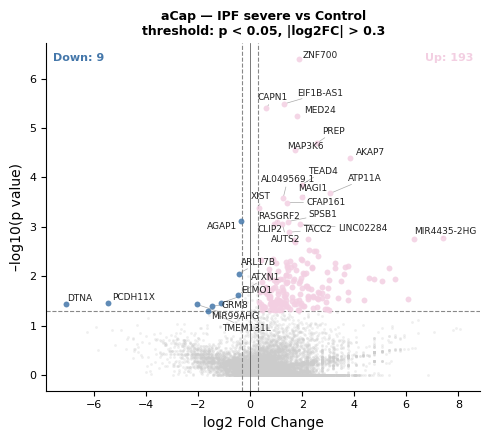

In [20]:
plot_volcano(df_severe, "IPF severe vs Control", save =True, show = True,
             savepath=out_base +"volcano_aCap_severe_vs_control.pdf")

In [21]:
enr_severe_up, enr_severe_down = run_enrichr_up_down(
    glist_severe_up, glist_severe_down,
    outdir_up=f"{out_base}/severe_up",
    outdir_down=f"{out_base}/severe_down",
)

### Upregulated pathways

In [22]:
GO_severe_up   = load_results(f"{out_base}/severe_up", "GO_Biological_Process_2025")
GO_severe_up.head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Positive Regulation of Transcription by RNA Po...,24/983,0.000028,0.022636,0,0,2.791073,29.28037,HDAC4;WWTR1;ARF4;HDAC5;CREBBP;CD40;AUTS2;FOXF1...
1,GO_Biological_Process_2025,Positive Regulation of DNA-templated Transcrip...,28/1274,0.000038,0.022636,0,0,2.527886,25.73423,HDAC4;ARF4;HDAC5;CD40;FOXK1;TEAD1;CDK5RAP2;WWT...
2,GO_Biological_Process_2025,Positive Regulation of RNA Biosynthetic Proces...,16/555,0.000101,0.040250,0,0,3.231429,29.72625,HDAC4;CREBBP;FOXF1;MCRS1;FOXK1;KLF4;SMARCA2;ME...
3,GO_Biological_Process_2025,Ubiquitin-Dependent Protein Catabolic Process ...,14/455,0.000142,0.042274,0,0,3.434601,30.43864,CRBN;FEM1B;CUL3;VPS37A;ARMC8;KLHL24;CBL;SPSB1;...
4,GO_Biological_Process_2025,Proteasomal Protein Catabolic Process (GO:0010...,12/372,0.000277,0.066227,0,0,3.581400,29.33270,SPSB1;MIDN;CDC34;CRBN;FEM1B;CUL3;PSME4;KBTBD2;...
5,GO_Biological_Process_2025,Hippo Signaling (GO:0035329),3/20,0.000894,0.177829,0,0,18.380800,129.03770,TEAD4;WWTR1;TEAD1
6,GO_Biological_Process_2025,"Retrograde Vesicle-Mediated Transport, Golgi t...",4/47,0.001084,0.184912,0,0,9.727575,66.41046,ARF4;PITPNB;PLPP3;ERGIC1
7,GO_Biological_Process_2025,Regulation of Mitotic Metaphase/Anaphase Trans...,4/51,0.001474,0.219996,0,0,8.897895,58.01223,PHF10;CUL3;SMARCA2;CDK5RAP2
8,GO_Biological_Process_2025,Proteasome-Mediated Ubiquitin-Dependent Protei...,10/340,0.001777,0.233259,0,0,3.225203,20.42471,SPSB1;CDC34;CRBN;FEM1B;CUL3;KBTBD2;CTNNB1;ARMC...
9,GO_Biological_Process_2025,Regulation of Protein Localization to Nucleus ...,4/56,0.002087,0.233259,0,0,8.040293,49.62539,WWTR1;CREBBP;ATP13A2;IPO7


In [23]:
Msig_severe_up = load_results(f"{out_base}/severe_up", "MSigDB_Hallmark_2020")
Msig_severe_up.head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,8/200,0.000741,0.028911,0,0,4.417793,31.839480,SPSB1;BCL3;PLPP3;KLF4;LDLR;FOSL2;NFE2L2;B4GALT5
1,MSigDB_Hallmark_2020,G2-M Checkpoint,7/200,0.003346,0.065250,0,0,3.824670,21.800420,TLE3;SFPQ;NUMA1;CUL3;BCL3;DMD;CDC25B
2,MSigDB_Hallmark_2020,Mitotic Spindle,6/199,0.012909,0.119365,0,0,3.260758,14.183810,CLIP2;FGD4;TRIO;NUMA1;RAPGEF5;CDK5RAP2
3,MSigDB_Hallmark_2020,Myogenesis,6/200,0.013204,0.119365,0,0,3.243784,14.036500,TEAD4;WWTR1;HDAC5;COL4A2;DMD;SORBS1
4,MSigDB_Hallmark_2020,TGF-beta Signaling,3/54,0.015303,0.119365,0,0,6.116409,25.564710,FKBP1A;WWTR1;CTNNB1
5,MSigDB_Hallmark_2020,Cholesterol Homeostasis,3/74,0.034804,0.226227,0,0,4.389029,14.738440,HMGCS1;CTNNB1;LDLR
6,MSigDB_Hallmark_2020,mTORC1 Signaling,5/200,0.044850,0.249877,0,0,2.674850,8.303906,TES;HMGCS1;PITPNB;INSIG1;LDLR
7,MSigDB_Hallmark_2020,Wnt-beta Catenin Signaling,2/42,0.062022,0.302357,0,0,5.174607,14.386800,HDAC5;CTNNB1
8,MSigDB_Hallmark_2020,Apoptosis,4/161,0.070852,0.307026,0,0,2.648873,7.011986,CREBBP;EMP1;CTNNB1;CDC25B
9,MSigDB_Hallmark_2020,Hypoxia,4/200,0.128619,0.501613,0,0,2.117590,4.342970,TES;UGP2;KLHL24;FOSL2


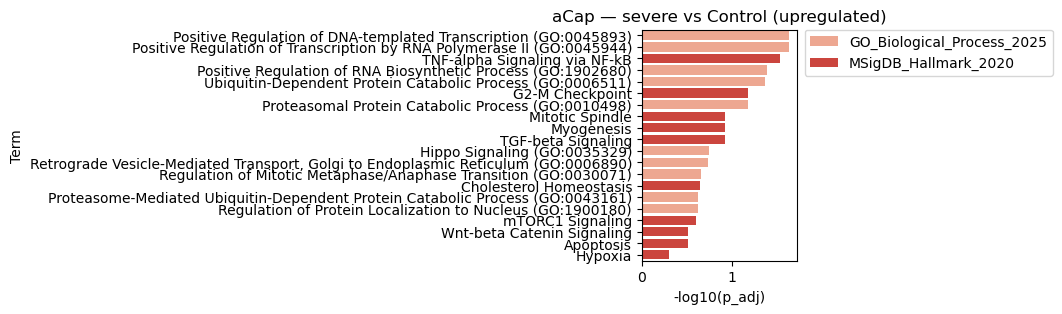

In [24]:
fig_severe_up, sel_severe_up = make_barplot(
    GO_severe_up, Msig_severe_up,
    go_idx=range(0, 10), msig_idx=range(0, 10),
    title="aCap — severe vs Control (upregulated)",
    savepath=f"{out_base}/aCap_severe_up.pdf",
)

### Downregulated pathways

In [25]:
GO_severe_down   = load_results(f"{out_base}/severe_down", "GO_Biological_Process_2025")
GO_severe_down.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Negative Regulation of T Cell Differentiation ...,1/6,0.002697,0.059340,0,0,499.65000,2955.6900,TMEM131L
1,GO_Biological_Process_2025,Regulation of Immature T Cell Proliferation in...,1/6,0.002697,0.059340,0,0,499.65000,2955.6900,TMEM131L
2,GO_Biological_Process_2025,Synaptic Signaling (GO:0099536),1/10,0.004492,0.065880,0,0,277.52780,1500.1740,DTNA
3,GO_Biological_Process_2025,G Protein-Coupled Glutamate Receptor Signaling...,1/14,0.006284,0.066478,0,0,192.09620,973.8925,GRM8
4,GO_Biological_Process_2025,Rac Protein Signal Transduction (GO:0016601),1/18,0.008072,0.066478,0,0,146.86760,707.7996,ELMO1
5,GO_Biological_Process_2025,Neuromuscular Synaptic Transmission (GO:0007274),1/21,0.009412,0.066478,0,0,124.81870,582.3731,DTNA
6,GO_Biological_Process_2025,Plasma Membrane Invagination (GO:0099024),1/27,0.012087,0.066478,0,0,95.98558,423.8372,ELMO1
7,GO_Biological_Process_2025,"Phagocytosis, Engulfment (GO:0006911)",1/27,0.012087,0.066478,0,0,95.98558,423.8372,ELMO1
8,GO_Biological_Process_2025,Glutamate Receptor Signaling Pathway (GO:0007215),1/36,0.016087,0.069752,0,0,71.27143,294.3331,GRM8
9,GO_Biological_Process_2025,Learning (GO:0007612),1/44,0.019630,0.069752,0,0,57.98837,227.9335,ATXN1


In [26]:
Msig_severe_down = load_results(f"{out_base}/severe_down", "MSigDB_Hallmark_2020")
Msig_severe_down.head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,Pperoxisome,1/104,0.045847,0.086499,0,0,24.13592,74.39765,ATXN1
1,MSigDB_Hallmark_2020,Bile Acid Metabolism,1/112,0.049295,0.086499,0,0,22.38739,67.38449,ATXN1
2,MSigDB_Hallmark_2020,Spermatogenesis,1/135,0.059147,0.086499,0,0,18.52332,52.37907,GRM8
3,MSigDB_Hallmark_2020,UV Response Dn,1/144,0.062977,0.086499,0,0,17.34965,47.97160,ATXN1
4,MSigDB_Hallmark_2020,Myogenesis,1/200,0.086499,0.086499,0,0,12.43216,30.42923,DTNA
5,MSigDB_Hallmark_2020,Hypoxia,1/200,0.086499,0.086499,0,0,12.43216,30.42923,DTNA


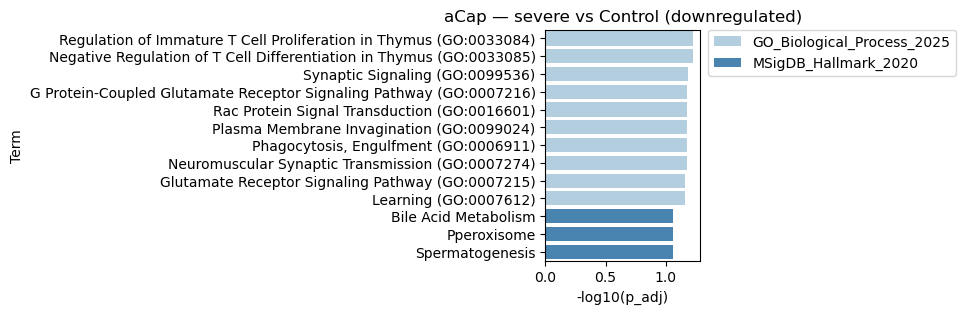

In [27]:
fig_severe_down, sel_severe_down = make_barplot(
    GO_severe_down, Msig_severe_down,
    go_idx=range(0, 10), msig_idx=range(0, 3),
    title="aCap — severe vs Control (downregulated)",
    savepath=f"{out_base}/aCap_severe_down.pdf",
    palette="Blues",
)

In [28]:
print(f"Mild vs Control — up: {len(glist_mild_up)}, down: {len(glist_mild_down)}")
print(f"Severe vs Control — up: {len(glist_severe_up)}, down: {len(glist_severe_down)}")

Mild vs Control — up: 3765, down: 825
Severe vs Control — up: 193, down: 9


In [29]:
print("Upregulated genes (Mild vs Control):")
print(glist_mild_up)

Upregulated genes (Mild vs Control):
['NCKAP5', 'TCF4', 'XIST', 'COL4A2', 'LDB2', 'EPB41L4A', 'SORBS1', 'SH3RF3', 'RAPGEF5', 'ID1', 'MAGI1', 'PRICKLE2', 'GRK5', 'SIK2', 'PACS1', 'WWTR1', 'COL4A1', 'PIK3R3', 'AC010974.2', 'F2RL3', 'SGK1', 'RGCC', 'PLXNA2', 'PTCHD4', 'WARS', 'CMTM8', 'PLPP3', 'PRKCE', 'SMAD6', 'ID3', 'IL1RL1', 'FENDRR', 'JAG1', 'BCL2L14', 'CLDN5', 'ACSL3', 'ADAM19', 'AL157871.4', 'MN1', 'SEC14L1', 'SMURF2', 'PODXL', 'AL356124.1', 'CFAP161', 'SUFU', 'PRDM1', 'RALGAPA2', 'TGFBR1', 'VPS37A', 'ENG', 'TRIM8', 'ADCY4', 'HYAL2', 'VIPR1', 'ITGA1', 'FAT1', 'ABHD17C', 'PXDN', 'SEMA3A', 'DOCK6', 'ITPKB', 'PDGFB', 'CEMIP2', 'TBX3', 'FOXF1', 'HLA-B', 'SLC26A2', 'AL353138.1', 'FZD4', 'AL137139.2', 'TMEM100', 'SPOCK2', 'PDE8A', 'AUTS2', 'PHLDA1', 'EML1', 'TMEM108', 'HLA-E', 'NAV1', 'SKIL', 'FKBP1A', 'NFKBIA', 'HLA-A', 'PREX1', 'PALD1', 'LRP6', 'BMPR2', 'GLUD1', 'ZSWIM6', 'BICD1', 'SNRK', 'STARD4', 'MAGI1-AS1', 'NCKAP5-AS1', 'ABCG1', 'STXBP6', 'TMEM184B', 'PREP', 'BMP6', 'SIPA1L2', 'RAP

In [30]:
print("Upregulated genes (Severe vs Control):")
print(glist_severe_up)

Upregulated genes (Severe vs Control):
['ZNF700', 'EIF1B-AS1', 'CAPN1', 'MED24', 'PREP', 'MAP3K6', 'AKAP7', 'TEAD4', 'ATP11A', 'MAGI1', 'AL049569.1', 'CFAP161', 'XIST', 'SPSB1', 'RASGRF2', 'AUTS2', 'CLIP2', 'LINC02284', 'TACC2', 'MIR4435-2HG', 'TMEM241', 'PTCHD4', 'IMPACT', 'INTS1', 'DAB2IP', 'ITPR1', 'AC018816.1', 'TMBIM1', 'PPP1R13B', 'MYO10', 'PPIH', 'TOM1L2', 'AFAP1', 'KLF4', 'EPHA1-AS1', 'DOCK6', 'ATP13A2', 'NEAT1', 'BTBD7', 'KRTAP5-AS1', 'NDUFA9', 'TCF4', 'TLE3', 'CHPF2', 'GORASP2', 'TMEM248', 'TMPRSS5', 'LZTR1', 'FCF1', 'ZNF287', 'TMC7', 'TES', 'SEPTIN8', 'MAGI1-AS1', 'SIK3', 'KBTBD2', 'KLC2', 'NOL4L', 'EVC', 'SORBS1', 'NFE2L2', 'AGBL3', 'INSIG1', 'MFSD14B', 'FGD4', 'AL157834.1', 'NHSL1', 'BLCAP', 'AKNAD1', 'AAMDC', 'HDAC4', 'WDR53', 'TTC13', 'UNC5B', 'AC005674.2', 'CERS6', 'RAPGEF5', 'SFPQ', 'PLD3', 'MIER2', 'MIDN', 'PTCD1', 'SNX8', 'AL592183.1', 'MFSD11', 'TMEM256', 'LYPLAL1', 'NRG3', 'CREBBP', 'ARF4', 'MCRS1', 'CD40', 'UGP2', 'CTNNB1', 'LDLRAD4', 'SMARCA2', 'CMC1', 'SIMC1', '

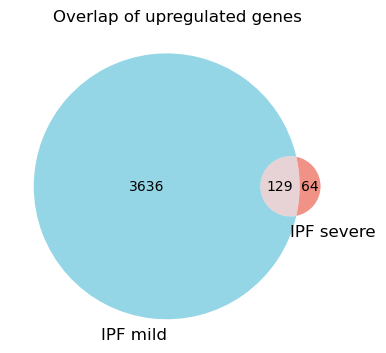

Overlap genes: 129
['AAMDC', 'AC005674.2', 'AFAP1', 'AGBL3', 'AKNAD1', 'AL049569.1', 'AL157834.1', 'AL353138.1', 'AL354822.1', 'AL592183.1', 'ANO2', 'ARF4', 'ARMC8', 'ATP11A', 'ATP13A2', 'AUTS2', 'B4GALT5', 'BCL3', 'BLCAP', 'BMPER', 'BTBD7', 'CARS', 'CBL', 'CD40', 'CDC25B', 'CDC34', 'CFAP161', 'CHPF2', 'COL4A2', 'CREBBP', 'CRK', 'CTNNB1', 'CUL3', 'CUZD1', 'DAAM1', 'DAB2IP', 'DENND3', 'DLST', 'DMD', 'DNAJC14', 'DOCK6', 'ELF2', 'EMP1', 'ERGIC1', 'EVC', 'EXOC2', 'FCF1', 'FKBP1A', 'FOSL2', 'FOXF1', 'FOXK1', 'GORASP2', 'H2AFY', 'HDAC4', 'IMPACT', 'INKA1', 'INSIG1', 'INTS1', 'KBTBD2', 'KCTD20', 'KIAA2026', 'KLC2', 'KLF4', 'KRTAP5-AS1', 'LARP4B', 'LDLR', 'LDLRAD4', 'LINC01509', 'LRRC40', 'MAGI1', 'MAGI1-AS1', 'MAP3K6', 'MCRS1', 'MFSD11', 'MFSD14B', 'MIDN', 'MIER2', 'MIR4435-2HG', 'MN1', 'MON1B', 'MVB12A', 'MYO10', 'N4BP3', 'NAA15', 'NDUFA9', 'NEAT1', 'NFATC3', 'NFE2L2', 'NOL4L', 'NRG3', 'OBSCN', 'PAK1IP1', 'PITPNB', 'PLPP3', 'PPIH', 'PPP1R13B', 'PREP', 'PSME4', 'PTCD1', 'PTCHD4', 'RAPGEF5', '

In [31]:
from matplotlib_venn import venn2
mild_up = set(glist_mild_up)
severe_up = set(glist_severe_up)

overlap_genes = mild_up & severe_up

plt.figure(figsize=(4, 4))

venn2(
    [mild_up, severe_up],
    set_labels=("IPF mild", "IPF severe"),
    set_colors=("#4DBBD5", "#E64B35"),
    alpha=0.6,
)

plt.title("Overlap of upregulated genes")
plt.tight_layout()
plt.show()

print(f"Overlap genes: {len(overlap_genes)}")
print(sorted(overlap_genes))